# Movie Rating Prediction using Linear Regression and Random Forest

Linear Regression
MAE: 1.077955716107759
MSE: 1.793238025494594
RMSE: 1.3391183762067467
R2: 0.035450225863035256

Random Forest
MAE: 1.0241217382154884
MSE: 1.6474983374894783
RMSE: 1.2835491176770284
R2: 0.1138409253405096
       Actual Rating  Predicted Rating
9456             3.3             5.307
14816            5.3             5.725
3213             5.7             5.528
3778             7.2             6.390
5775             3.5             4.525


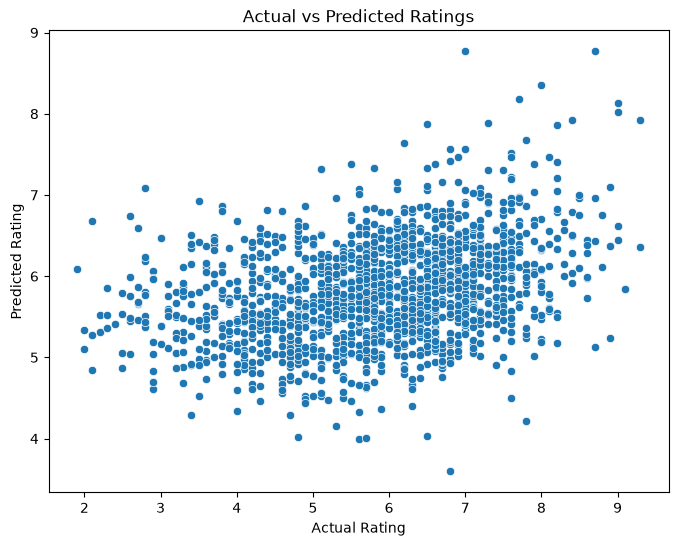

    Feature  Importance
1  Director    0.205154
0     Genre    0.199711
2   Actor 1    0.198629
4   Actor 3    0.198545
3   Actor 2    0.197961


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

movie_data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

movie_data = movie_data.dropna(subset=['Rating'])
for c in ['Genre','Director','Actor 1','Actor 2','Actor 3']:
    movie_data[c]=movie_data[c].fillna("Unknown")

le=LabelEncoder()
for c in ['Genre','Director','Actor 1','Actor 2','Actor 3']:
    movie_data[c]=le.fit_transform(movie_data[c])

X=movie_data[['Genre','Director','Actor 1','Actor 2','Actor 3']]
Y=movie_data['Rating']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

lr=LinearRegression()
lr.fit(X_train,Y_train)
lr_pred=lr.predict(X_test)

print("Linear Regression")
print("MAE:",mean_absolute_error(Y_test,lr_pred))
print("MSE:",mean_squared_error(Y_test,lr_pred))
print("RMSE:",np.sqrt(mean_squared_error(Y_test,lr_pred)))
print("R2:",r2_score(Y_test,lr_pred))

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,Y_train)
rf_pred=rf.predict(X_test)

print("\nRandom Forest")
print("MAE:",mean_absolute_error(Y_test,rf_pred))
print("MSE:",mean_squared_error(Y_test,rf_pred))
print("RMSE:",np.sqrt(mean_squared_error(Y_test,rf_pred)))
print("R2:",r2_score(Y_test,rf_pred))

result=pd.DataFrame({'Actual Rating':Y_test,'Predicted Rating':rf_pred})
print(result.head())

plt.figure(figsize=(8,6))
sns.scatterplot(x=Y_test,y=rf_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

importance=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
print(importance.sort_values(by='Importance',ascending=False))
